## Problem 6.1 - Performance of random Gaussian setting

In [9]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_spd_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [10]:
#define covariance matrix and parameters
np.random.seed(42)
Cov = make_spd_matrix(7)
theta_star = np.ones(7)
d = 8
sigma = 0.3
n_values = np.round(np.power(10,np.linspace(1,3,15))).astype(int)

In [11]:
# function to generate gaussian distributed data
def myfunc(n, Cov):
    Z = np.random.normal(0,1,[7,n])
    x = (Cov @ Z).T
    epsilon = np.random.normal(0,sigma,n)
    y = x @ theta_star + epsilon
    return x, y

In [12]:
errors = []
for n in n_values:
    outer_risks = []

    for _ in range(100):
        x0, y0 = myfunc(n, Cov)
        model = LinearRegression(fit_intercept = False)
        model.fit(x0, y0)

        inner_risks = []
        for _ in range(500):
            x, y = myfunc(n, Cov)
            y_pred = model.predict(x)
            risk = mean_squared_error(y, y_pred)
            inner_risks.append(risk)

        outer_risks.append(np.mean(inner_risks))
        
    estimated_lsr = np.mean(outer_risks)
    errors.append(estimated_lsr - sigma**2)

In [20]:
# compute theoretical approximation error
theoretical_errors = []
for n in n_values:
    error = (sigma**2 * d) / (n * ( 1 - (d + 1) / n ))
    theoretical_errors.append(error)

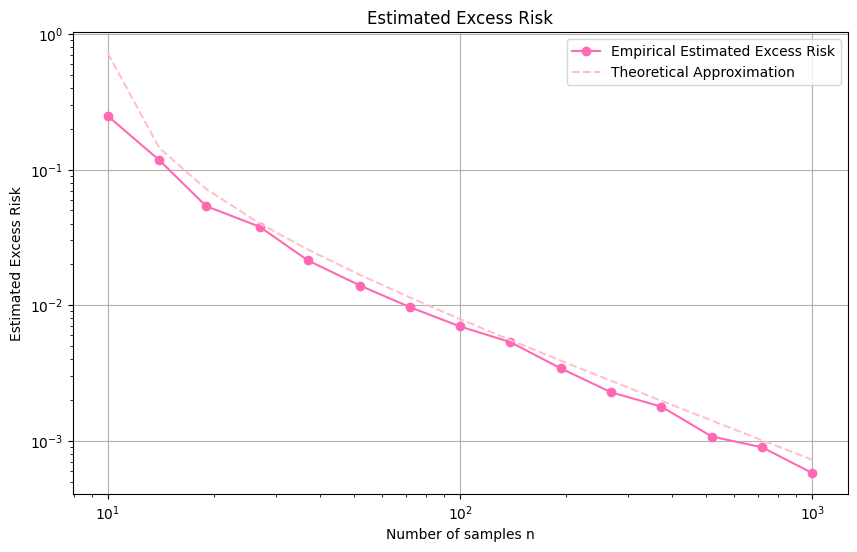

In [22]:
# plot the results
plt.figure(figsize=(10,6))
plt.loglog(n_values, errors, marker = 'o', color = 'hotpink')
plt.loglog(n_values, theoretical_errors, linestyle = '--', color = 'pink')
plt.xlabel('Number of samples n')
plt.ylabel('Estimated Excess Risk')
plt.title('Estimated Excess Risk')
plt.legend(['Empirical Estimated Excess Risk', 'Theoretical Approximation'])
plt.grid(True)
plt.show()